# Fisher-Rao penalty diagnostic sweep

Training data only (first 80 curves). Goal: find where the penalty is doing real work
vs. saturating at the low end (warp ceiling) or high end (identity collapse).

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skfda import FDataGrid
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.registration import FisherRaoElasticRegistration

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV, load_edf

plt.style.use('../imagestyle.mplstyle')

ROOT    = Path('..')
CSV     = ROOT / 'Kural_Dataset' / 'eeg_summary.csv'
EDF_DIR = ROOT / 'Kural_Dataset' / 'Recordings'

In [2]:
manifest = load_CSV(CSV)

SFREQ     = 500.0
HALF_N    = int(1.0 * SFREQ)          # 500 samples
PEAK_HALF = int(round(0.1 * SFREQ))   # ±0.1 s for channel selection

curves, labels = [], []
for _, row in manifest.iterrows():
    raw   = load_edf(row['file_id'], EDF_DIR)
    onset = int(round(row['transient_onset_s'] * SFREQ))
    data  = raw.get_data(start=onset - HALF_N, stop=onset + HALF_N)
    ch    = np.argmax(np.ptp(data[:, HALF_N - PEAK_HALF: HALF_N + PEAK_HALF], axis=1))
    curves.append(data[ch])
    labels.append(row['label_binary'])

t  = (np.arange(2 * HALF_N) - HALF_N) / SFREQ
fd = FDataGrid(data_matrix=np.stack(curves), grid_points=t)
y  = np.array(labels)
print(f"Loaded {len(y)} curves")

Loaded 100 curves


In [3]:
# Training set only — same 80-curve split as classification_registered.ipynb
N_BASIS = 40
N_REG   = 100

fd_train = fd[:80]
y_train  = y[:80]

smoother  = BasisSmoother(BSplineBasis(domain_range=(t[0], t[-1]), n_basis=N_BASIS, order=4), return_basis=False)
fd_smooth = smoother.fit_transform(fd_train)

t_reg     = np.linspace(t[0], t[-1], N_REG)
fd_coarse = FDataGrid(fd_smooth(t_reg).squeeze(-1), t_reg)
print(f"Training set: {fd_coarse.data_matrix.shape}  (epileptic={y_train.sum()}, non={( y_train==0).sum()})")

Training set: (80, 100, 1)  (epileptic=46, non=34)


In [9]:
PENALTIES = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

results = {}
for p in PENALTIES:
    reg = FisherRaoElasticRegistration(penalty=p)
    reg.fit_transform(fd_coarse)
    warps   = reg.warping_.data_matrix[:, :, 0]   # (80, 100)
    dev     = np.abs(warps - t_reg)               # deviation from identity at each point
    max_dev = dev.max(axis=1)                      # per-curve max deviation
    results[p] = {
        'warps'       : warps,
        'mean_max_dev': max_dev.mean(),
        'epi_max_dev' : max_dev[y_train == 1].mean(),
        'non_max_dev' : max_dev[y_train == 0].mean(),
    }
    print(f"penalty={p:6.3f}  mean_max_dev={results[p]['mean_max_dev']:.4f}s  "
          f"epi={results[p]['epi_max_dev']:.4f}s  non={results[p]['non_max_dev']:.4f}s")

penalty= 0.001  mean_max_dev=0.2528s  epi=0.2457s  non=0.2624s
penalty= 0.005  mean_max_dev=0.2255s  epi=0.2167s  non=0.2374s
penalty= 0.010  mean_max_dev=0.2127s  epi=0.2045s  non=0.2238s
penalty= 0.050  mean_max_dev=0.1461s  epi=0.1422s  non=0.1514s
penalty= 0.100  mean_max_dev=0.1193s  epi=0.1185s  non=0.1205s
penalty= 0.500  mean_max_dev=0.0560s  epi=0.0535s  non=0.0594s
penalty= 1.000  mean_max_dev=0.0391s  epi=0.0355s  non=0.0439s
penalty= 5.000  mean_max_dev=0.0063s  epi=0.0057s  non=0.0071s
penalty=10.000  mean_max_dev=0.0003s  epi=0.0000s  non=0.0006s


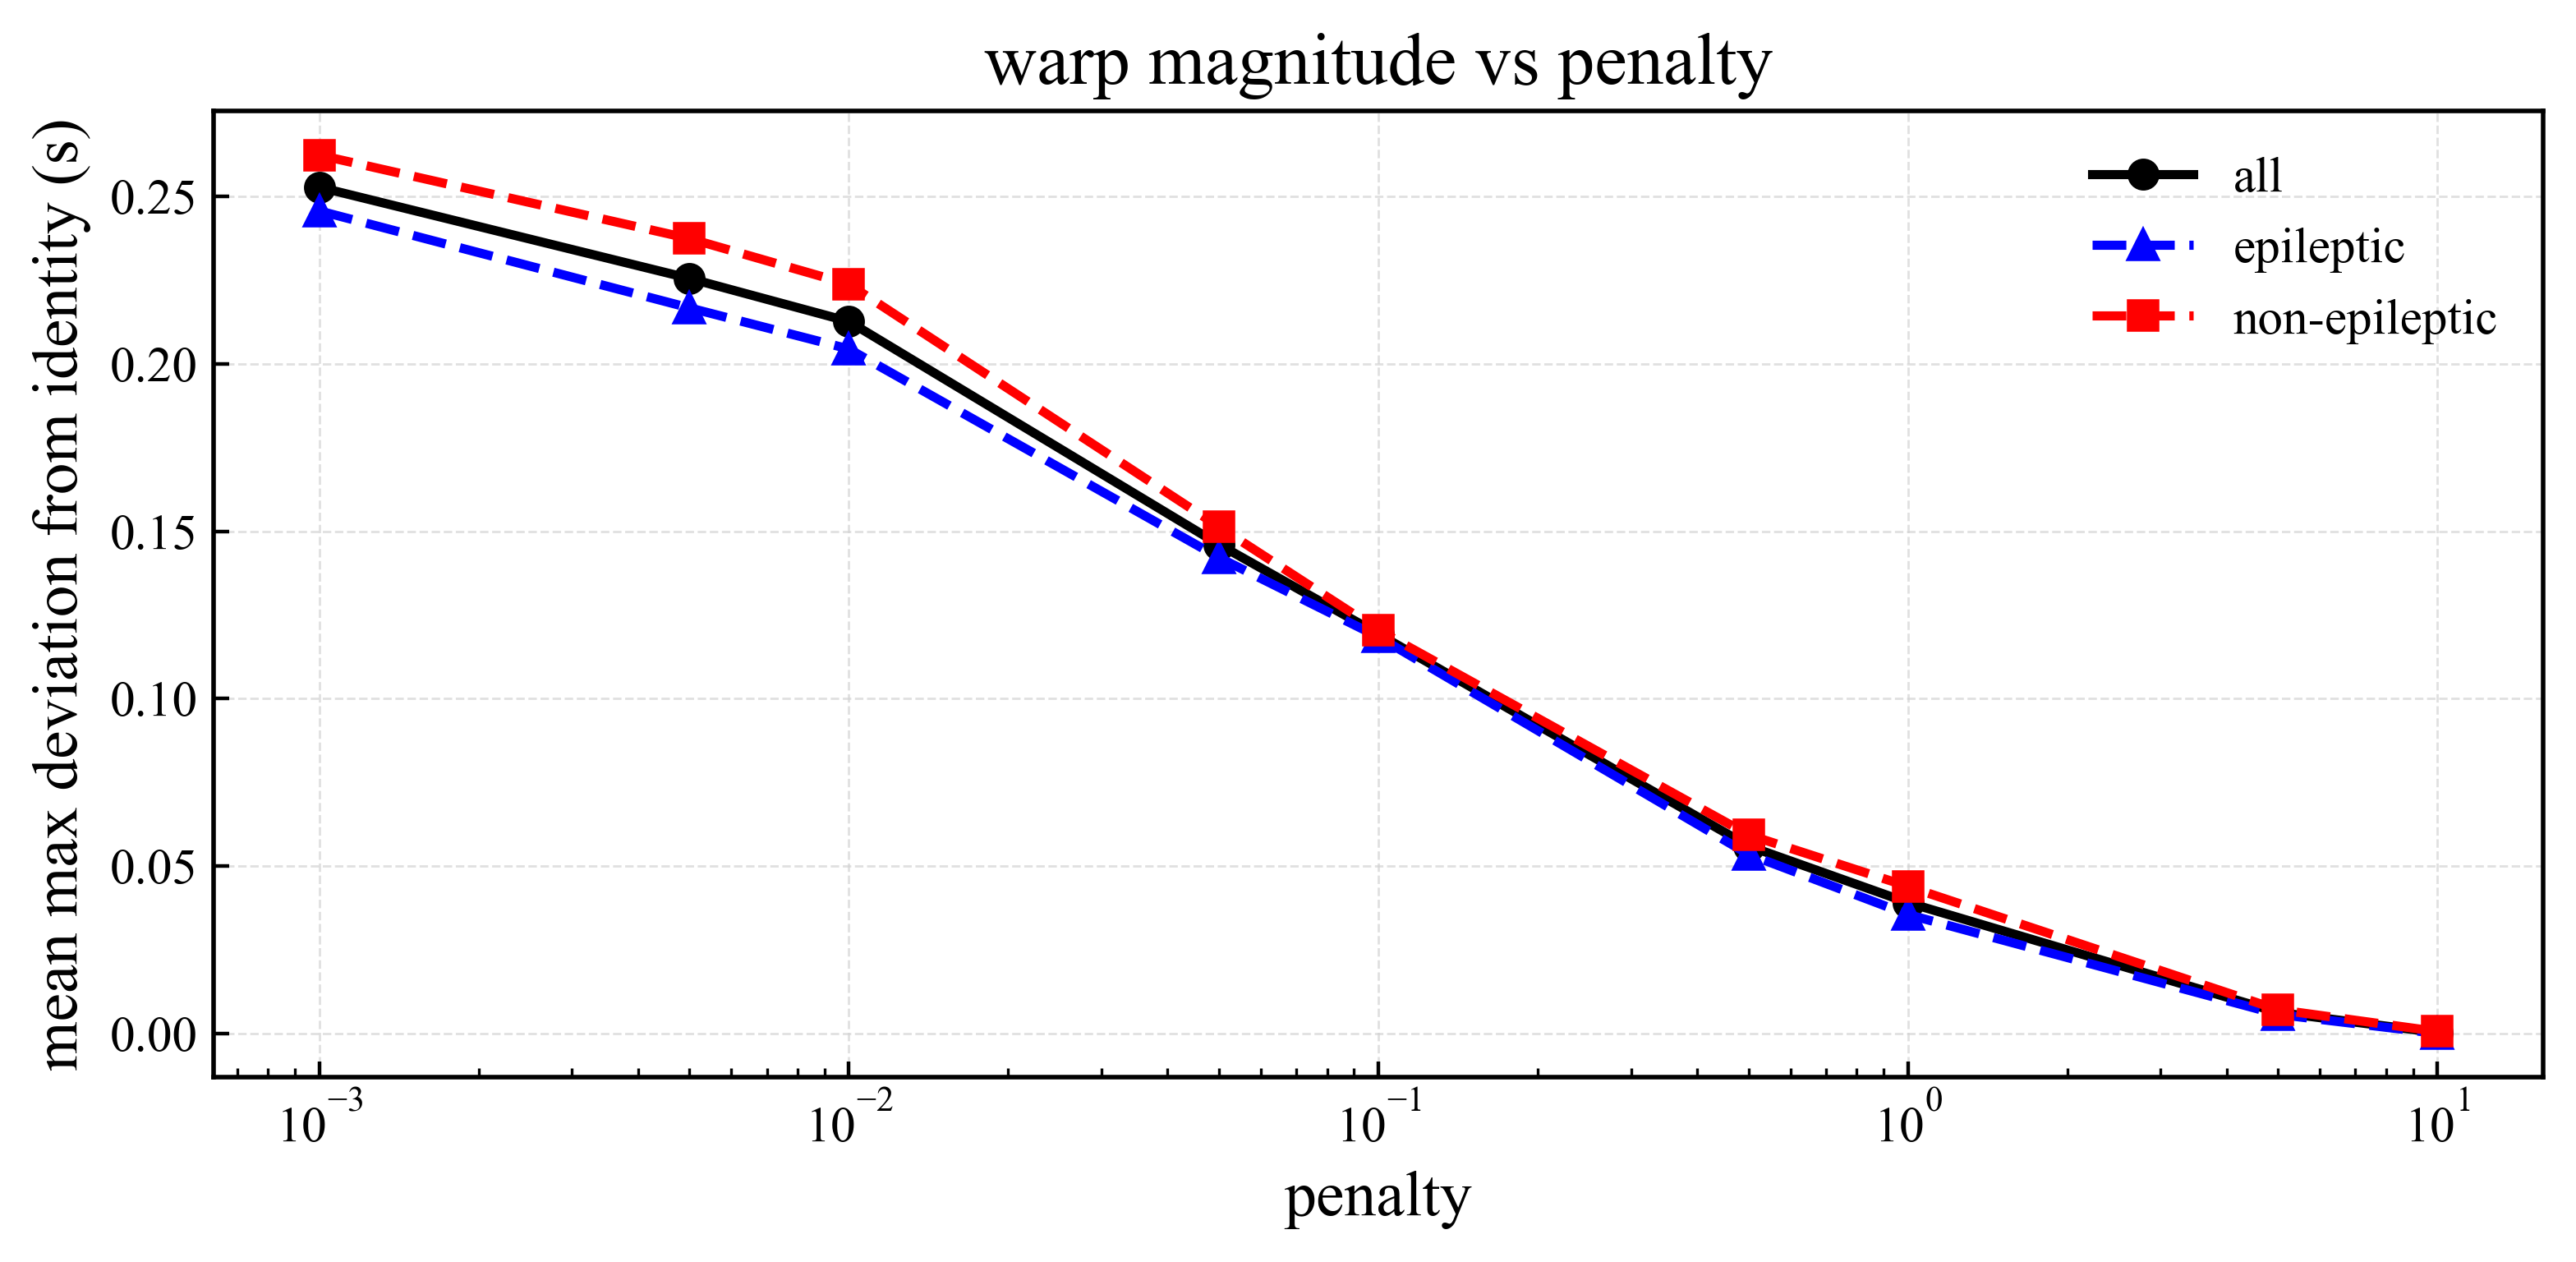

In [10]:
# Warp magnitude vs penalty
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(PENALTIES, [results[p]['mean_max_dev'] for p in PENALTIES], 'ko-',  label='all')
ax.semilogx(PENALTIES, [results[p]['epi_max_dev']  for p in PENALTIES], 'b^--', label='epileptic')
ax.semilogx(PENALTIES, [results[p]['non_max_dev']  for p in PENALTIES], 'rs--', label='non-epileptic')
ax.set_xlabel('penalty')
ax.set_ylabel('mean max deviation from identity (s)')
ax.set_title('warp magnitude vs penalty')
ax.legend()
plt.tight_layout()
plt.show()

The two classes warp by nearly the same amount. The epileptic and non-epileptic lines are almost on top of each other across most of the range. That means both classes need about the same amount of timing distortion to align. If timing were a distinguishing property of epileptic transients, you might expect one class to require systematically more or less warping than the other. It doesn't. This is independent corroboration of your phase result: the two groups don't differ in how much they warp, which is consistent with phase-only being near-chance. It's a second, simpler piece of evidence for "timing doesn't carry the signal," coming from the warp magnitudes directly rather than from a classifier.

At the aggressive end of the warping, non-epileptic (red) sits slightly above epileptic (blue), meaning non-epileptic curves warp a touch more when the penalty is very low. This could be differences in noise or background characteristics between groups.

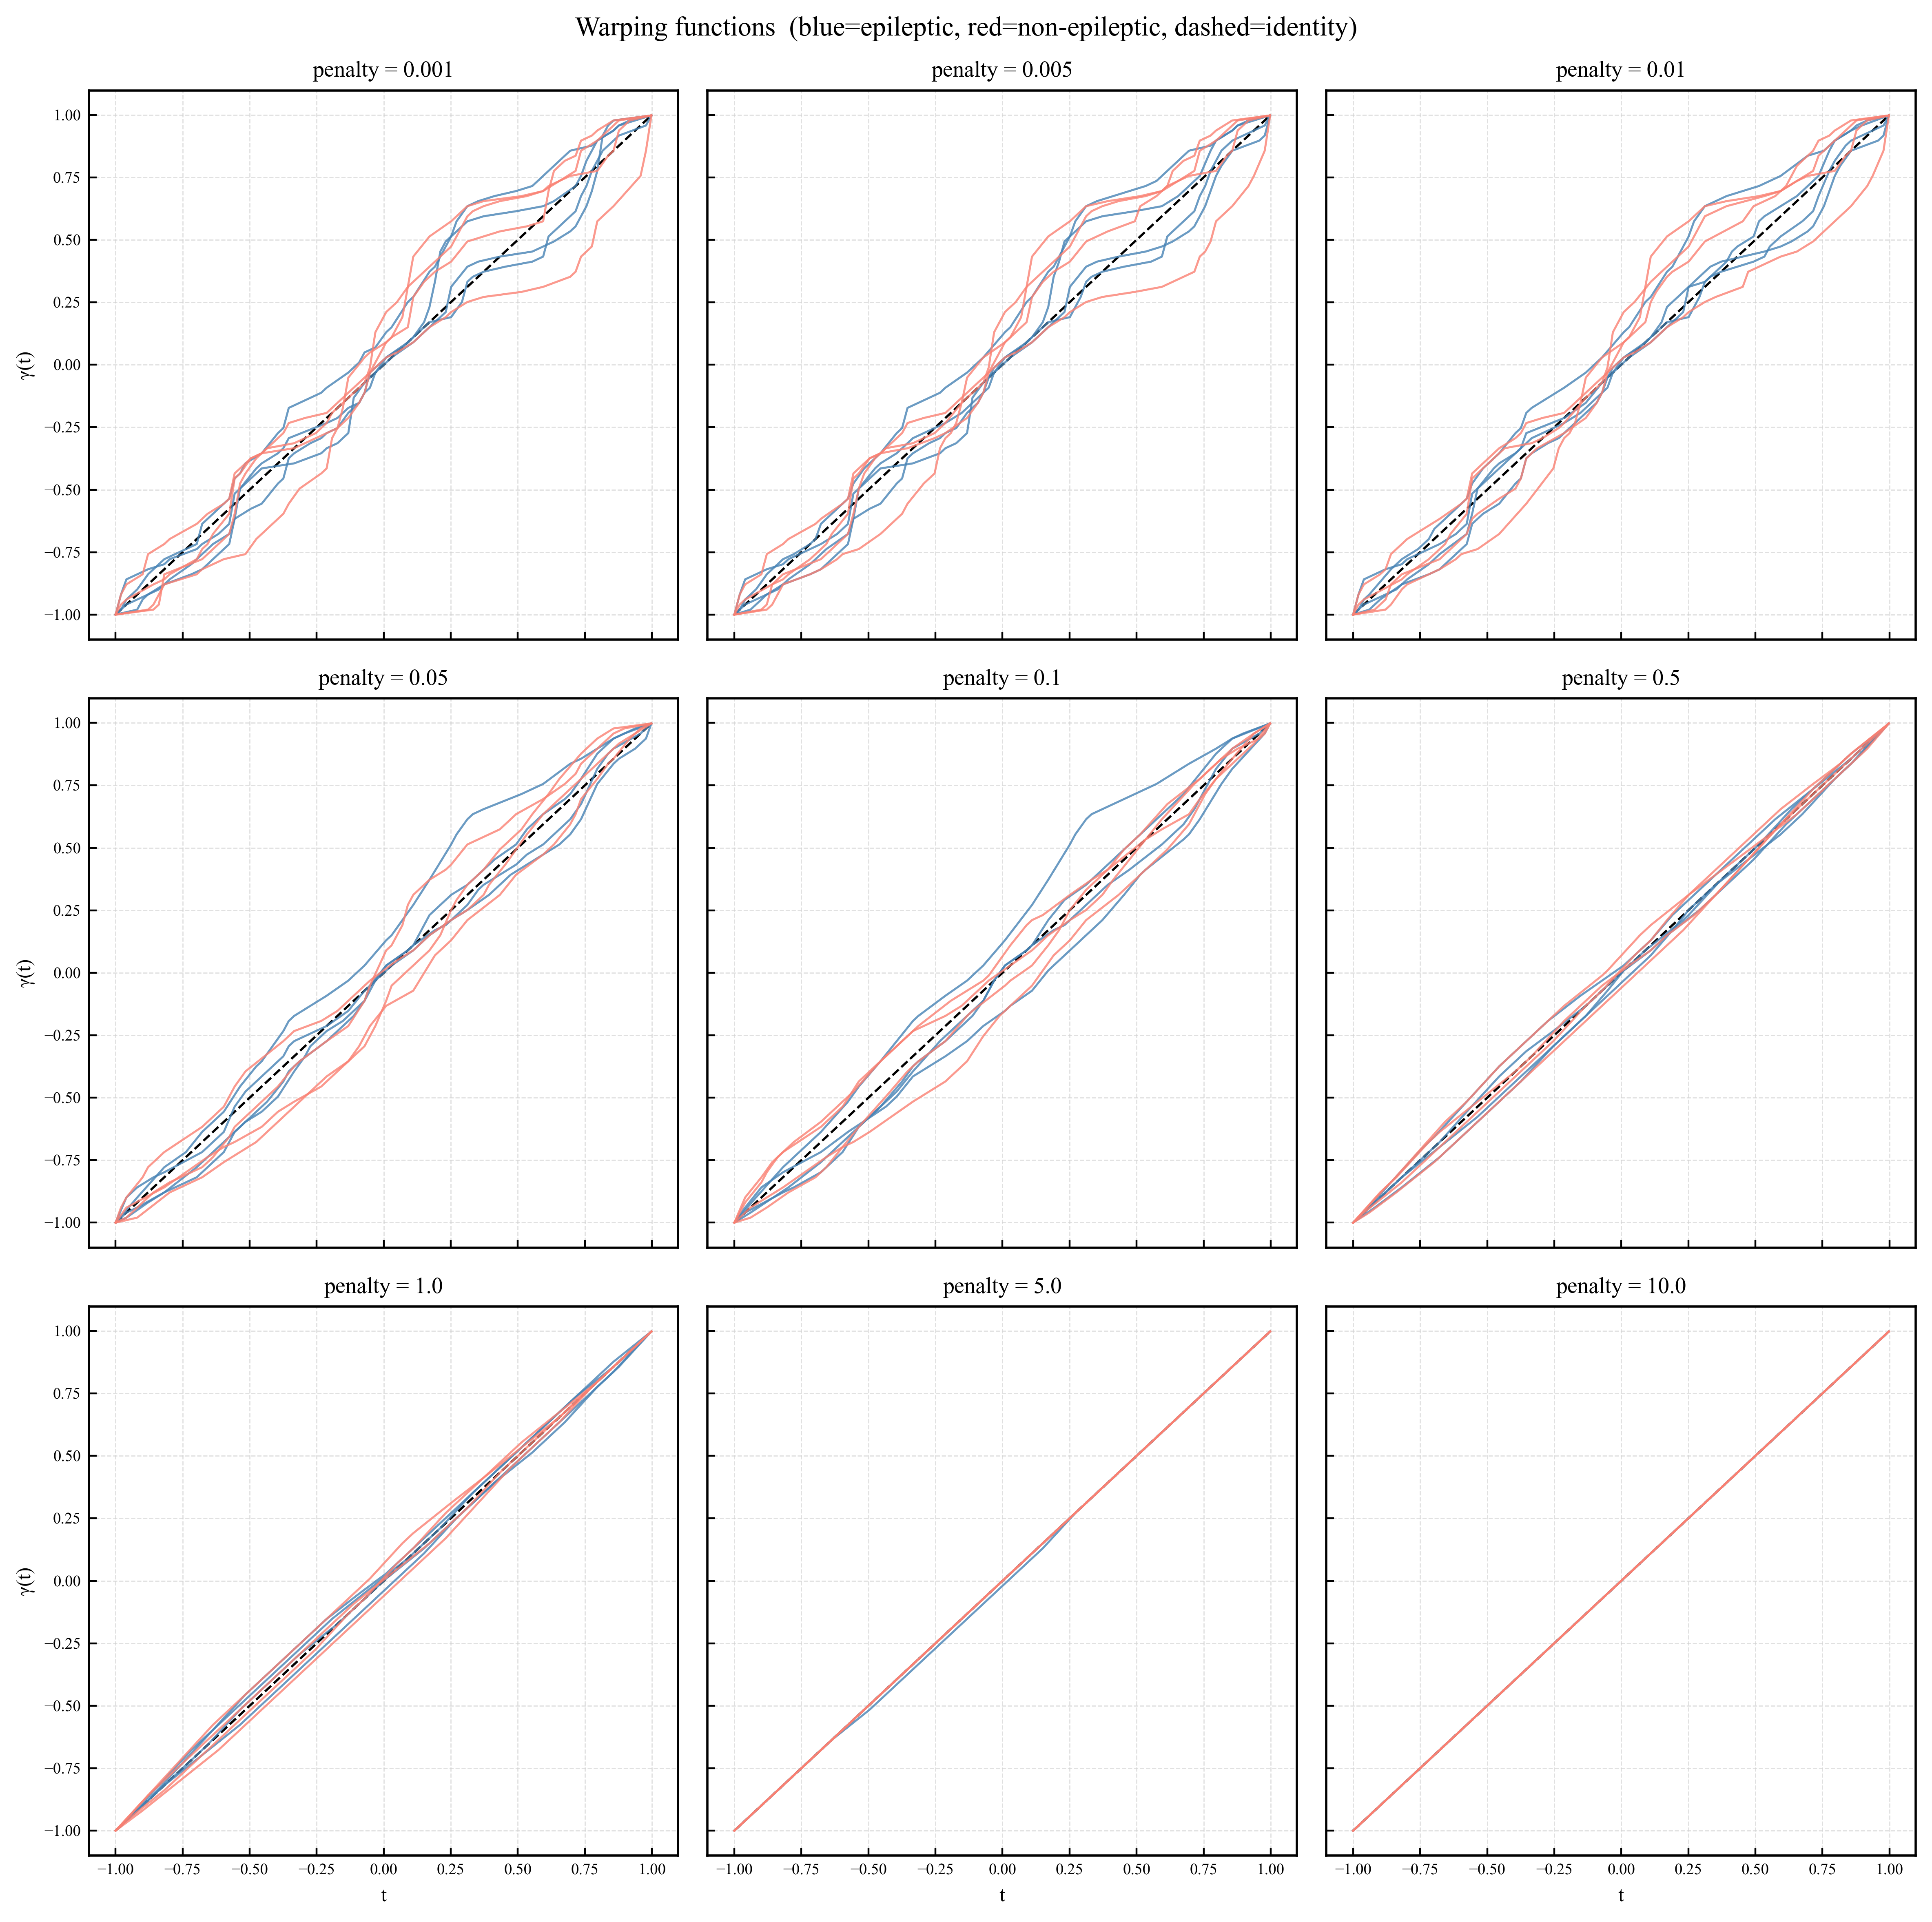

In [11]:
# Warping functions — a few epileptic and non-epileptic curves per penalty
N_SHOW  = 4
epi_idx = np.where(y_train == 1)[0][:N_SHOW]
non_idx = np.where(y_train == 0)[0][:N_SHOW]

fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=True, sharex=True)
axes_flat = axes.flatten()

for ax, p in zip(axes_flat, PENALTIES):
    warps = results[p]['warps']
    ax.plot(t_reg, t_reg, 'k--', lw=1)
    for i in epi_idx:
        ax.plot(t_reg, warps[i], color='steelblue', alpha=0.8, lw=0.9)
    for i in non_idx:
        ax.plot(t_reg, warps[i], color='salmon', alpha=0.8, lw=0.9)
    ax.set_title(f'penalty = {p}', fontsize=10)
    ax.tick_params(labelsize=7)

for ax in axes[:, 0]:
    ax.set_ylabel('γ(t)', fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel('t', fontsize=9)

fig.suptitle('Warping functions  (blue=epileptic, red=non-epileptic, dashed=identity)', fontsize=12)
plt.tight_layout()
plt.show()